In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Load dataset

df=pd.read_csv("dataset.csv")
print(df)
print(df.shape)
print(df.head())
print(df.tail())
print(df.columns)


     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0         522         7.93   Windy           Low   Afternoon      Scooter   
1         738        16.42   Clear        Medium     Evening         Bike   
2         741         9.52   Foggy           Low       Night      Scooter   
3         661         7.44   Rainy        Medium   Afternoon      Scooter   
4         412        19.03   Clear           Low     Morning         Bike   
..        ...          ...     ...           ...         ...          ...   
995       107         8.50   Clear          High     Evening          Car   
996       271        16.28   Rainy           Low     Morning      Scooter   
997       861        15.62   Snowy          High     Evening      Scooter   
998       436        14.17   Clear           Low   Afternoon         Bike   
999       103         6.63   Foggy           Low       Night      Scooter   

     Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0   

In [4]:
#---DATA PREPROCESSING--- 

#finding no. of missing values in each column
print(df.isnull().sum())

# Fill missing values

df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())


print(df)
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0         522         7.93   Windy           Low   Afternoon      Scooter   
1         738        16.42   Clear        Medium     Evening         Bike   
2         741         9.52   Foggy           Low       Night      Scooter   
3         661         7.44   Rainy        Medium   Afternoon      Scooter   
4         412        19.03   Clear           Low     Morning         Bike   
..        ...          ...     ...           ...         ...          ...   
995       107         8.50   Clear          High     Evening          Car   
996       271        16.28   Rainy           Low     Morning      Scooter   
997       861        15.62   Snow

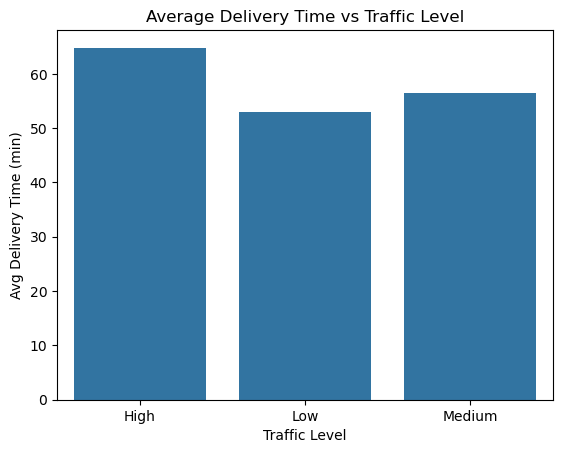

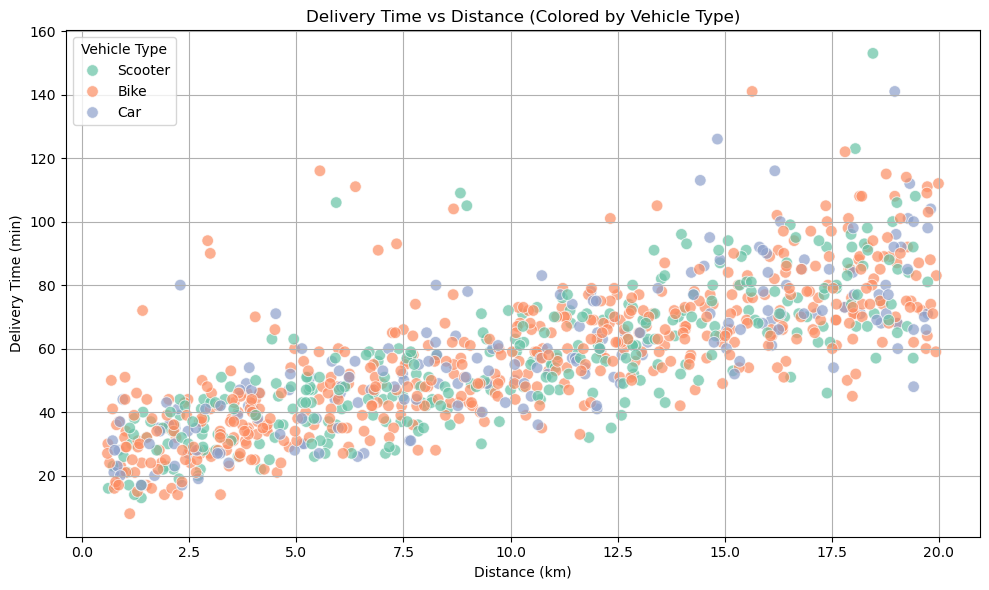

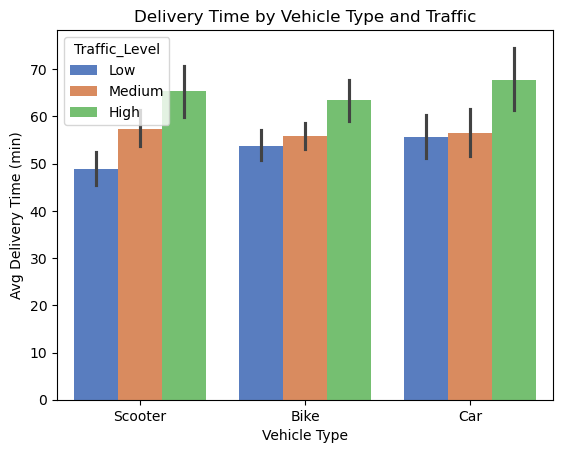

In [5]:
traffic_group = df.groupby('Traffic_Level')['Delivery_Time_min'].mean().reset_index()

sns.barplot(x='Traffic_Level', y='Delivery_Time_min', data=traffic_group)
plt.title("Average Delivery Time vs Traffic Level")
plt.ylabel("Avg Delivery Time (min)")
plt.xlabel("Traffic Level")
plt.show()


plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time_min',
    hue='Vehicle_Type',
    data=df,   # use unencoded data
    palette='Set2',
    s=70,
    alpha=0.7
)

plt.title("Delivery Time vs Distance (Colored by Vehicle Type)")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.legend(title="Vehicle Type")
plt.grid(True)
plt.tight_layout()
plt.show()


sns.barplot(x='Vehicle_Type', y='Delivery_Time_min', hue='Traffic_Level', data=df, palette='muted')
plt.title("Delivery Time by Vehicle Type and Traffic")
plt.ylabel("Avg Delivery Time (min)")
plt.xlabel("Vehicle Type")
plt.show()

In [40]:
# Label Encoding

le=LabelEncoder()
df['Weather']=le.fit_transform(df["Weather"])
df['Traffic_Level']=le.fit_transform(df["Traffic_Level"])
df['Time_of_Day']=le.fit_transform(df["Time_of_Day"])
df['Vehicle_Type']=le.fit_transform(df["Vehicle_Type"])
print(df)

# Standard Scaling

Scaler=StandardScaler()
df[['Order_ID','Distance_km','Weather','Traffic_Level','Time_of_Day','Vehicle_Type','Preparation_Time_min','Courier_Experience_yrs']]=Scaler.fit_transform(df[['Order_ID','Distance_km','Weather','Traffic_Level','Time_of_Day',
            'Vehicle_Type','Preparation_Time_min','Courier_Experience_yrs']])
print(df)

     Order_ID  Distance_km  Weather  Traffic_Level  Time_of_Day  Vehicle_Type  \
0         522         7.93        4              1            0             2   
1         738        16.42        0              2            1             0   
2         741         9.52        1              1            3             2   
3         661         7.44        2              2            0             2   
4         412        19.03        0              1            2             0   
..        ...          ...      ...            ...          ...           ...   
995       107         8.50        0              0            1             1   
996       271        16.28        2              1            2             2   
997       861        15.62        3              0            1             2   
998       436        14.17        0              1            0             0   
999       103         6.63        1              1            3             2   

     Preparation_Time_min  

In [41]:
# Split data

X = df[['Order_ID','Distance_km','Weather','Traffic_Level','Time_of_Day','Vehicle_Type','Preparation_Time_min','Courier_Experience_yrs']]
y = df['Delivery_Time_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
# --- Step 6: Predict for a New Data ---

new_order=[[912,14.5,'Windy','Low','Afternoon','Bike',15,15.0]]
columns = ['Order_ID','Distance_km','Weather','Traffic_Level','Time_of_Day',
           'Vehicle_Type','Preparation_Time_min','Courier_Experience_yrs']
new_order_df = pd.DataFrame(new_order, columns=columns)

# Encode new data using the same label encoders
le=LabelEncoder()
new_order_df ['Weather']=le.fit_transform(new_order_df ["Weather"])
new_order_df ['Traffic_Level']=le.fit_transform(new_order_df ["Traffic_Level"])
new_order_df ['Time_of_Day']=le.fit_transform(new_order_df ["Time_of_Day"])
new_order_df ['Vehicle_Type']=le.fit_transform(new_order_df ["Vehicle_Type"])

# Scale new data
new_order_scaled = Scaler.transform(new_order_df)

# Predict & Print the Value
predicted_Delivery_Time_min=model.predict(new_order_scaled)
print("Predicted  delivery time:",predicted_Delivery_Time_min[0])

Predicted  delivery time: 61.9716399465903


C:\Users\allis\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
